# Gaussian Mixture Models

## Overview

A Gaussian Mixture Model (GMM) represents the data as a weighted sum of k multivariate Gaussian distributions. Unlike k-means, GMMs produce **soft assignments** (probability of belonging to each component) and can capture elliptical cluster shapes.

**GMM vs k-means:**

| Property | K-means | GMM |
|---|---|---|
| Assignment | Hard (0/1) | Soft (probability) |
| Cluster shape | Spherical | Elliptical (covariance) |
| Outputs | Labels | Labels + probabilities |
| Model selection | Elbow/silhouette | BIC / AIC |

Covariance types: `full` (each cluster has its own covariance), `tied` (shared), `diag` (diagonal), `spherical` (like k-means). Start with `full`; use `diag` or `spherical` for small n.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal

rng = np.random.default_rng(42)
# Three elliptical clusters
X1 = rng.multivariate_normal([0,0],   [[3,2],[2,2]],  120)
X2 = rng.multivariate_normal([6,1],   [[1,0],[0,3]],  90)
X3 = rng.multivariate_normal([3,5],   [[2,-1],[-1,1]],100)
X = np.vstack([X1, X2, X3])
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f"Dataset: {X.shape}")

Dataset: (310, 2)


---
## Fitting and Soft Assignments

In [2]:
gmm = GaussianMixture(n_components=3, covariance_type="full",
                     n_init=10, random_state=42)
gmm.fit(X_sc)
labels = gmm.predict(X_sc)
probs  = gmm.predict_proba(X_sc)
print(f"BIC: {gmm.bic(X_sc):.2f}")
print(f"Log-likelihood: {gmm.score(X_sc):.4f}")
print(f"Converged: {gmm.converged_}")
print("\nFirst 5 soft assignment probabilities:")
print(np.round(probs[:5], 3))
print("\nComponent weights:", np.round(gmm.weights_, 3))

BIC: 1382.35
Log-likelihood: -2.0723
Converged: True

First 5 soft assignment probabilities:
[[1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.753 0.019 0.229]
 [1.    0.    0.   ]
 [1.    0.    0.   ]]

Component weights: [0.386 0.336 0.278]


---
## Model Selection: BIC and AIC

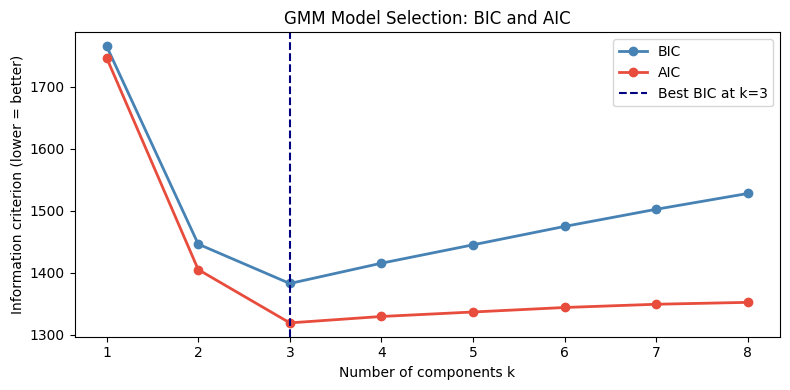

BIC selects k=3, AIC selects k=3


In [3]:
ks = range(1, 9)
bics, aics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type="full",
                        n_init=10, random_state=42).fit(X_sc)
    bics.append(g.bic(X_sc))
    aics.append(g.aic(X_sc))
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ks, bics, "o-", color="steelblue", lw=2, label="BIC")
ax.plot(ks, aics, "o-", color="#e74c3c",   lw=2, label="AIC")
best_k = ks[np.argmin(bics)]
ax.axvline(best_k, color="navy", lw=1.5, linestyle="--", label=f"Best BIC at k={best_k}")
ax.set_xlabel("Number of components k")
ax.set_ylabel("Information criterion (lower = better)")
ax.set_title("GMM Model Selection: BIC and AIC")
ax.legend(); plt.tight_layout(); plt.show()
print(f"BIC selects k={best_k}, AIC selects k={ks[np.argmin(aics)]}")

---
## Visualising Elliptical Clusters

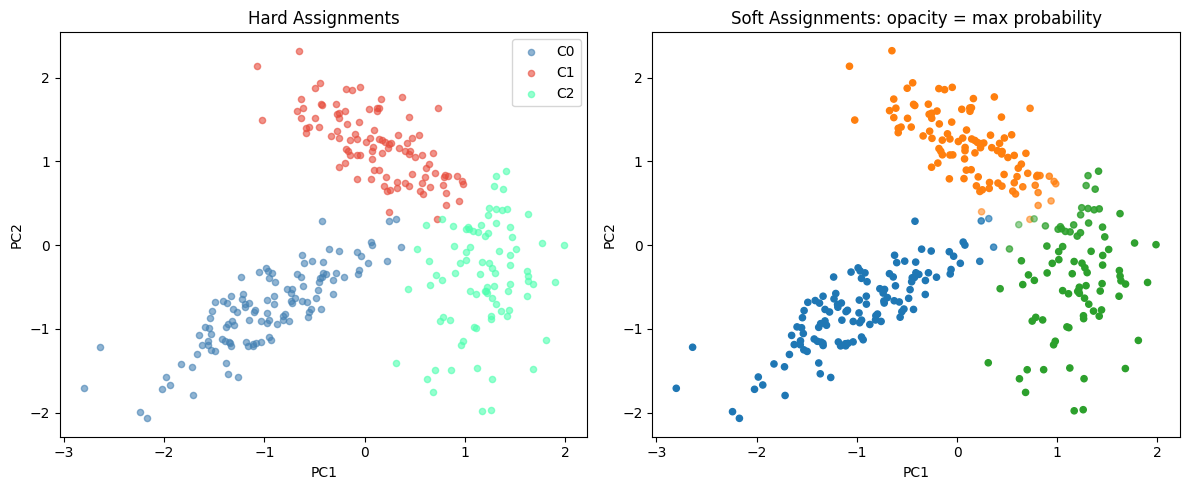

In [4]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
colors = ["steelblue","#e74c3c","#4fffb0"]
# Hard assignments
for k in range(3):
    mask = labels == k
    axes[0].scatter(X_sc[mask,0], X_sc[mask,1], s=20, alpha=0.6,
                    color=colors[k], label=f"C{k}")
axes[0].set_title("Hard Assignments"); axes[0].legend()
# Soft: colour by max probability (opacity = confidence)
max_prob = probs.max(axis=1)
cmap_labels = np.array([colors[l] for l in labels])
axes[1].scatter(X_sc[:,0], X_sc[:,1], s=20, alpha=max_prob*0.9+0.1,
                c=[plt.cm.tab10(l/10) for l in labels])
axes[1].set_title("Soft Assignments: opacity = max probability")
for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

---
## Covariance Type Comparison

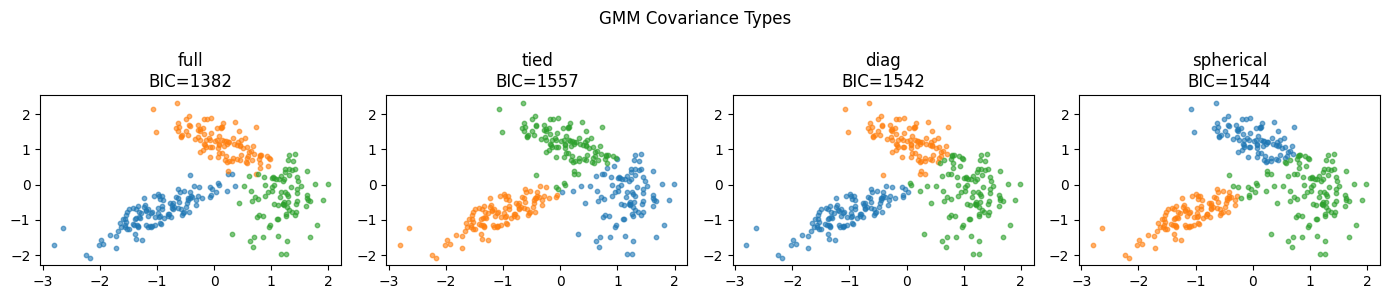

In [5]:
fig, axes = plt.subplots(1,4,figsize=(14,3))
for ax, cov in zip(axes, ["full","tied","diag","spherical"]):
    g = GaussianMixture(n_components=3, covariance_type=cov,
                        n_init=10, random_state=42).fit(X_sc)
    lbl = g.predict(X_sc)
    for k in range(3):
        mask = lbl == k
        ax.scatter(X_sc[mask,0], X_sc[mask,1], s=10, alpha=0.6)
    ax.set_title(f"{cov}\nBIC={g.bic(X_sc):.0f}")
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("GMM Covariance Types")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using `full` covariance with small n relative to p**  
Full covariance estimates k * p*(p+1)/2 parameters. For small samples this can cause singular covariance matrices and fitting failures. Use `diag` or `spherical` covariance when n is small, or add regularisation via `reg_covar`.

**2. Not checking for convergence**  
GMM uses EM, which can fail to converge or converge to a poor local maximum. Always check `gmm.converged_` and use `n_init >= 10` to refit from multiple initialisations.

**3. Using BIC/AIC as the only selection criterion**  
BIC penalises complexity and tends to select fewer components; AIC favours more. Neither captures whether the clusters are scientifically meaningful. Supplement information criteria with silhouette scores and domain interpretation of cluster profiles.

**4. Treating GMM as a density estimator and a clustering tool simultaneously**  
GMMs are generative models — they model the full data distribution. The component labels are a by-product. For density estimation use the log-likelihood; for clustering use the predicted labels. Conflating the two leads to misinterpretation.

**5. Not standardising before fitting**  
Like k-means, GMM distances and covariances are scale-sensitive. Always standardise features before fitting, and interpret cluster centroids by inverse-transforming back to the original scale.

---
*python_methods_library - Samantha McGarrigle*